In [1]:
from matplotlib import pyplot as plt
import numpy as np

### Метод Эйлера

In [2]:
x0 = 1
y_prev = 2
h = 0.2
f = lambda x, y: y - x ** 2
fi = round(f(x0, y_prev), 4)
Dy = round(h * fi, 4)

In [3]:
X = [x0]
Y = [y_prev]

In [4]:
for i in range(1, 6):
    xi = x0 + h * i
    yi = round(y_prev + Dy, 4)
    print(xi, yi)
    X.append(xi)
    Y.append(yi)
    fi = f(xi, yi)
    Dy = h * fi
    y_prev = yi

1.2 2.2
1.4 2.352
1.6 2.4304
1.8 2.4045
2.0 2.2374


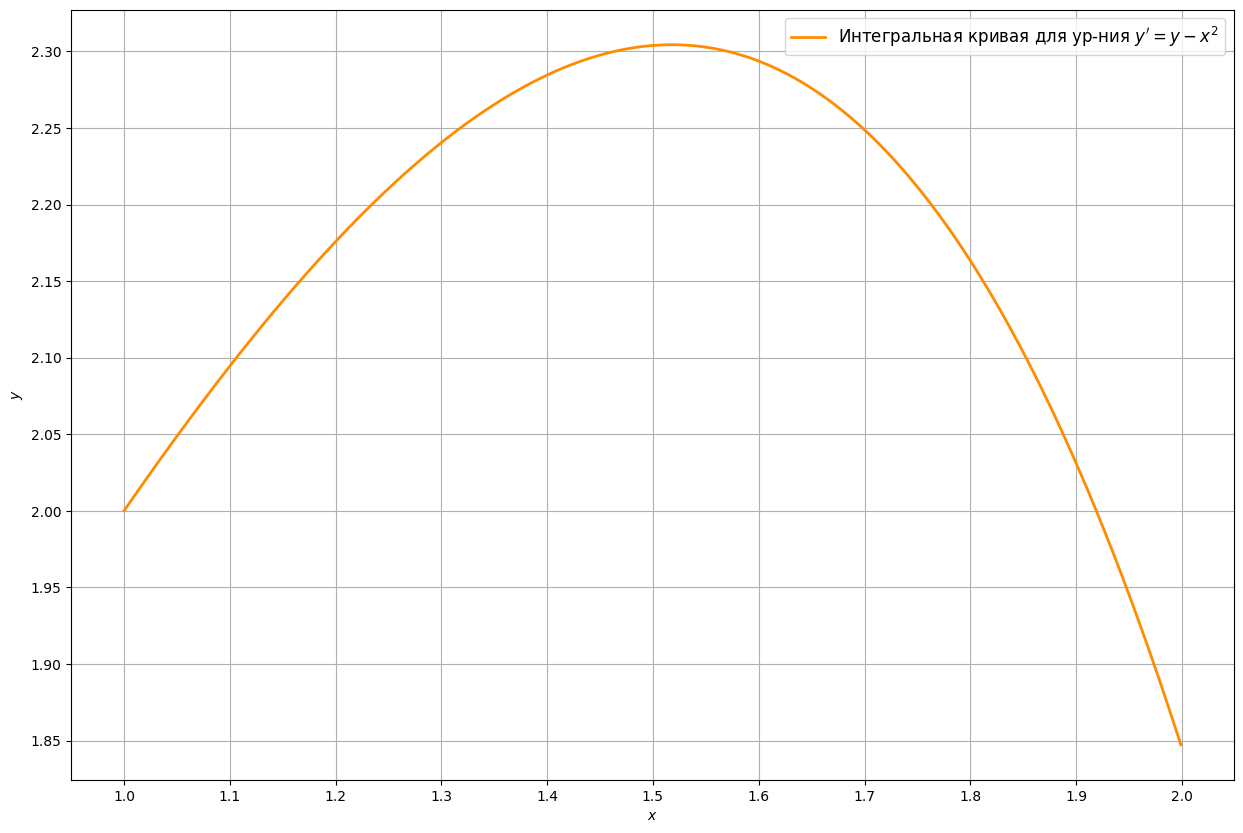

In [7]:
figure, axes = plt.subplots(figsize=(15, 10))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
axes.set_xticks(np.arange(X[0], X[-1] + 0.1, 0.1))
axes.set_yticks(np.arange(Y[0] - 1, max(Y) + 0.05, 0.05))

axes.scatter(X, Y, zorder=2, label=r"$(x_i, y_i)$")
axes.plot(X, Y, zorder=2, linewidth=2, label=r"Кривая, полученная методом Эйлера")

true_X = np.arange(1, 2, 0.001)
true_Y = true_X ** 2 + 2 * true_X + 2 - 3 * np.e ** (true_X - 1)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y'=y-x^2$")


axes.grid()
axes.legend(fontsize="large")

### Модифицированный метод Эйлера

In [100]:
x0 = 1
y_prev = 2
h = 0.2
f = lambda x, y: y - x ** 2
xi_12 = round(x0 + h / 2, 4)
fi = round(f(x0, y_prev), 4)
y_prev_12 = round(y_prev + h * fi / 2, 4)
Dy = round(h * f(xi_12, y_prev_12), 4)

In [101]:
X2 = [x0]
Y2 = [y_prev]

In [102]:
for i in range(1, 6):
    xi = x0 + i * h
    yi = round(y_prev + Dy, 4)

    X2.append(xi)
    Y2.append(yi)

    xi_12 = round(xi + h / 2, 4)
    fi = round(f(xi, yi), 4)
    yi_12 = round(yi + h * fi / 2, 4)

    Dy = round(h * f(xi_12, yi_12), 4)
    print(yi, xi_12, fi, yi_12, Dy, sep="\t")
    y_prev = yi


2.178	1.3	0.738	2.2518	0.1124
2.2904	1.5	0.3304	2.3234	0.0147
2.3051	1.7	-0.2549	2.2796	-0.1221
2.183	1.9	-1.057	2.0773	-0.3065
1.8765	2.1	-2.1235	1.6642	-0.5492


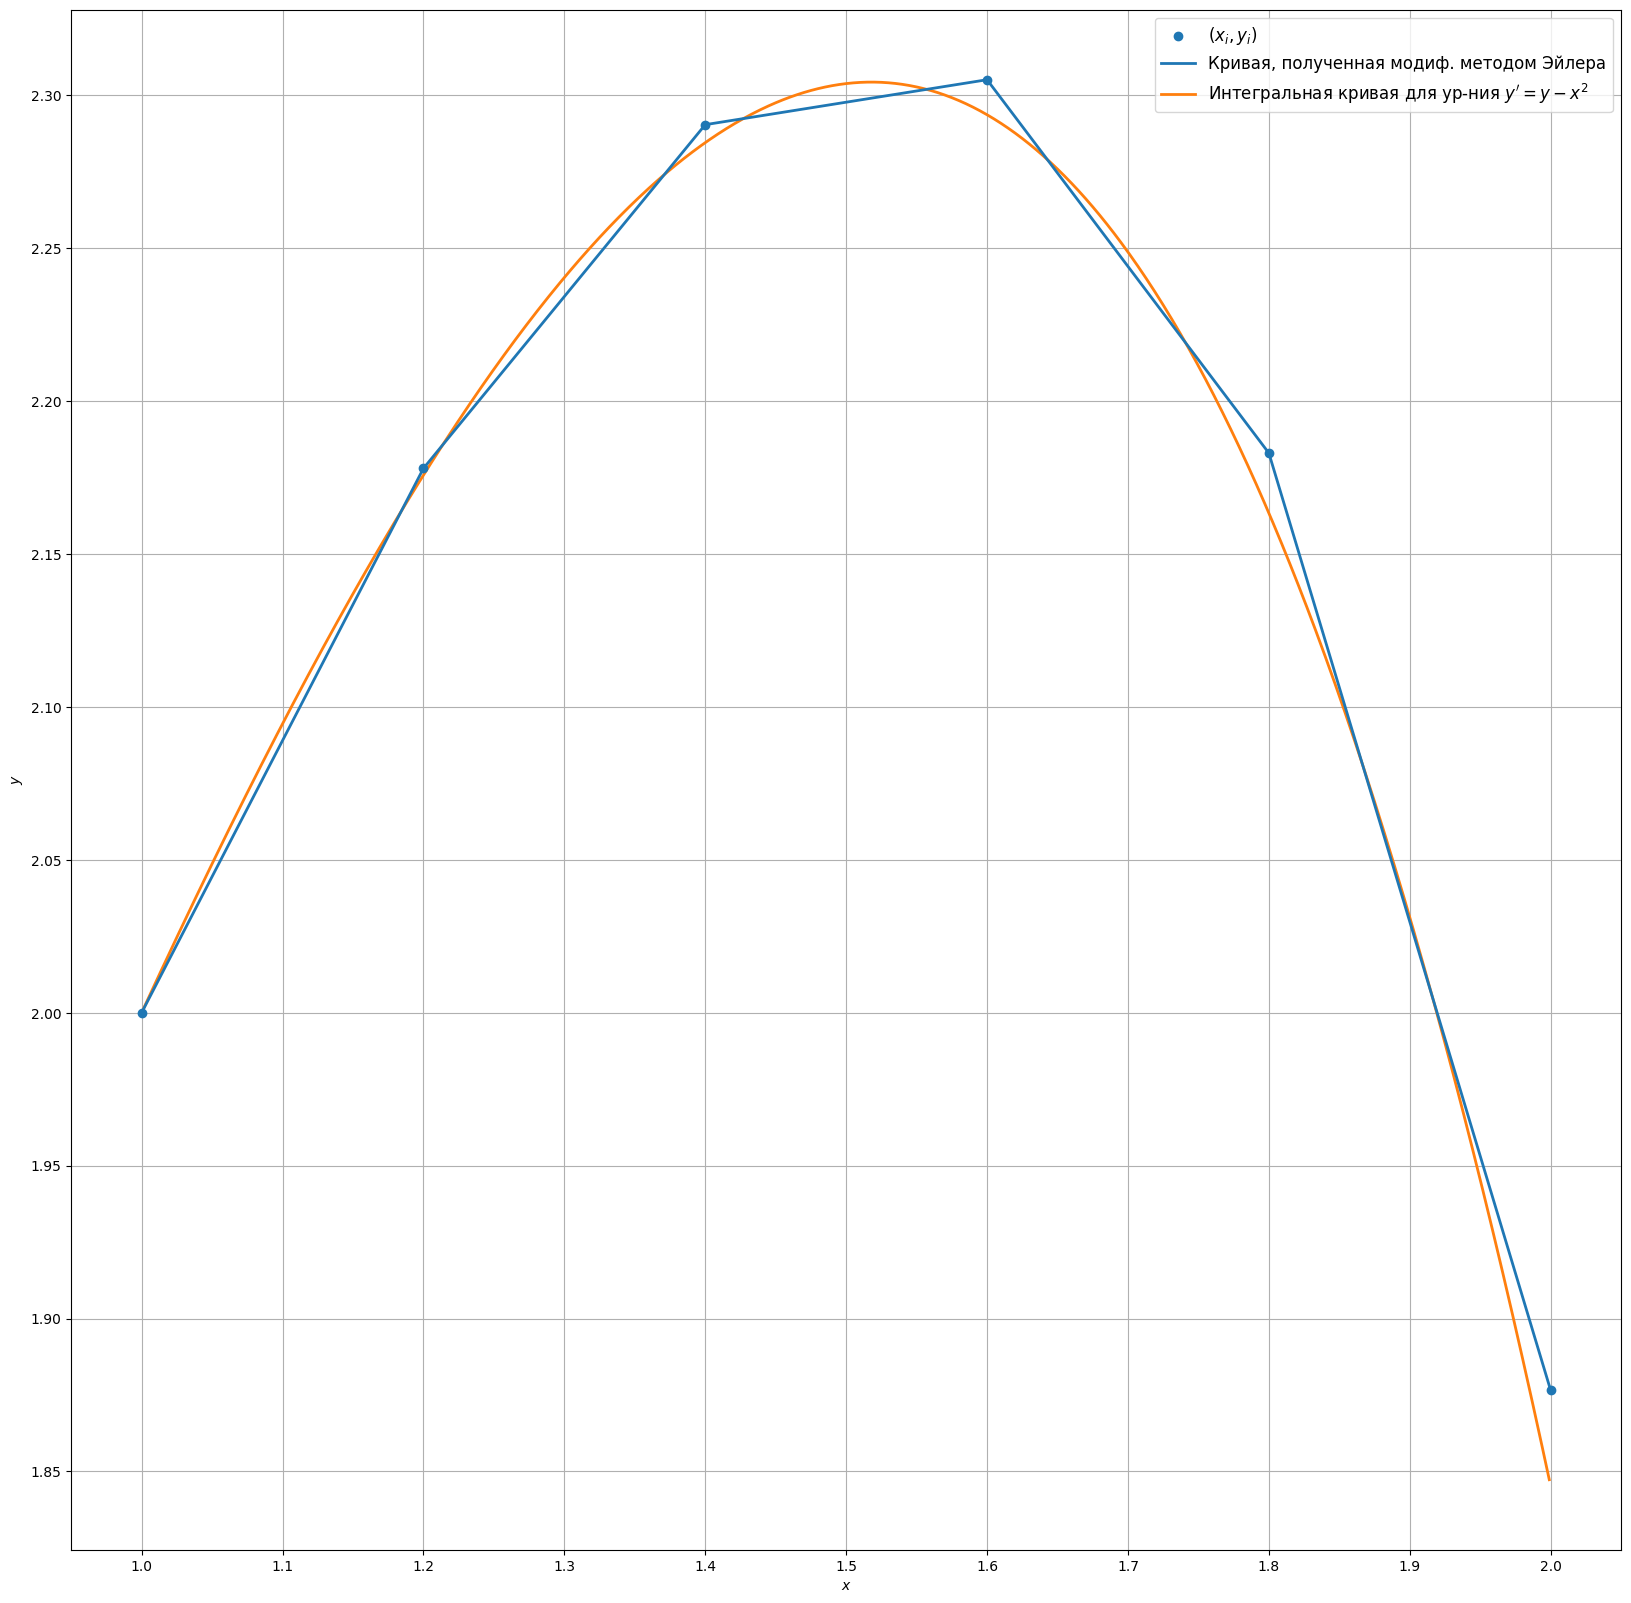

In [105]:
figure, axes = plt.subplots(figsize=(20, 20))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
axes.set_xticks(np.arange(X2[0], X2[-1] + 0.1, 0.1))
axes.set_yticks(np.arange(Y2[0] - 1, max(Y2) + 0.05, 0.05))

axes.scatter(X2, Y2, zorder=2, label=r"$(x_i, y_i)$")
axes.plot(X2, Y2, zorder=2, linewidth=2, label=r"Кривая, полученная модиф. методом Эйлера")

true_X = np.arange(1, 2, 0.001)
true_Y = true_X ** 2 + 2 * true_X + 2 - 3 * np.e ** (true_X - 1)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y'=y-x^2$")


axes.grid()
axes.legend(fontsize="large")

### Метод Рунге-Кутта

In [111]:
x0 = xi = 1
y_prev = 2
h = 0.2
f = lambda x, y: y - x ** 2

In [112]:
X3 = [x0]
Y3 = [y_prev]

In [113]:
for i in range(0, 5):
    K1 = round(h * f(xi, y_prev), 4)
    K2 = round(h * f(xi + h / 2, y_prev + K1 / 2), 4)
    K3 = round(h * f(xi + h / 2, y_prev + K2 / 2), 4)
    K4 = round(h * f(xi + h, y_prev + K3), 4)
    Dy = round((K1 + 2 * K2 + 2 * K3 + K4) / 6, 4)
    print(i, 1, round(xi, 4), y_prev, K1, K1, sep="\t")
    print(i, 2, round(xi + h / 2, 4), round(y_prev + K1 / 2, 4), K2, 2 * K2, sep="\t")
    print(i, 3, round(xi + h / 2, 4), round(y_prev + K2 / 2, 4), K3, 2 * K3, sep="\t")
    print(i, 4, round(xi + h, 4), round(y_prev + K3, 4), K4, K4, sep="\t")
    print(i, 5, " ", " ", " ", Dy, sep="\t")
    y_prev = round(y_prev + Dy, 4)
    xi = round(x0 + h * (i + 1), 4)
    X3.append(xi)
    Y3.append(y_prev)


0	1	1	2	0.2	0.2
0	2	1.1	2.1	0.178	0.356
0	3	1.1	2.089	0.1758	0.3516
0	4	1.2	2.1758	0.1472	0.1472
0	5	 	 	 	0.1758
1	1	1.2	2.1758	0.1472	0.1472
1	2	1.3	2.2494	0.1119	0.2238
1	3	1.3	2.2318	0.1084	0.2168
1	4	1.4	2.2842	0.0648	0.0648
1	5	 	 	 	0.1088
2	1	1.4	2.2846	0.0649	0.0649
2	2	1.5	2.3171	0.0134	0.0268
2	3	1.5	2.2913	0.0083	0.0166
2	4	1.6	2.2929	-0.0534	-0.0534
2	5	 	 	 	0.0092
3	1	1.6	2.2938	-0.0532	-0.0532
3	2	1.7	2.2672	-0.1246	-0.2492
3	3	1.7	2.2315	-0.1317	-0.2634
3	4	1.8	2.1621	-0.2156	-0.2156
3	5	 	 	 	-0.1302
4	1	1.8	2.1636	-0.2153	-0.2153
4	2	1.9	2.056	-0.3108	-0.6216
4	3	1.9	2.0082	-0.3204	-0.6408
4	4	2.0	1.8432	-0.4314	-0.4314
4	5	 	 	 	-0.3182


In [114]:
def func(x):
    return x ** 2 + 2 * x + 2 - 3 * np.e ** (x - 1)

In [115]:
for i in range(6):
    print(round(x0 + h * i, 4), round(func(x0 + h * i), 4))

1.0 2.0
1.2 2.1758
1.4 2.2845
1.6 2.2936
1.8 2.1634
2.0 1.8452


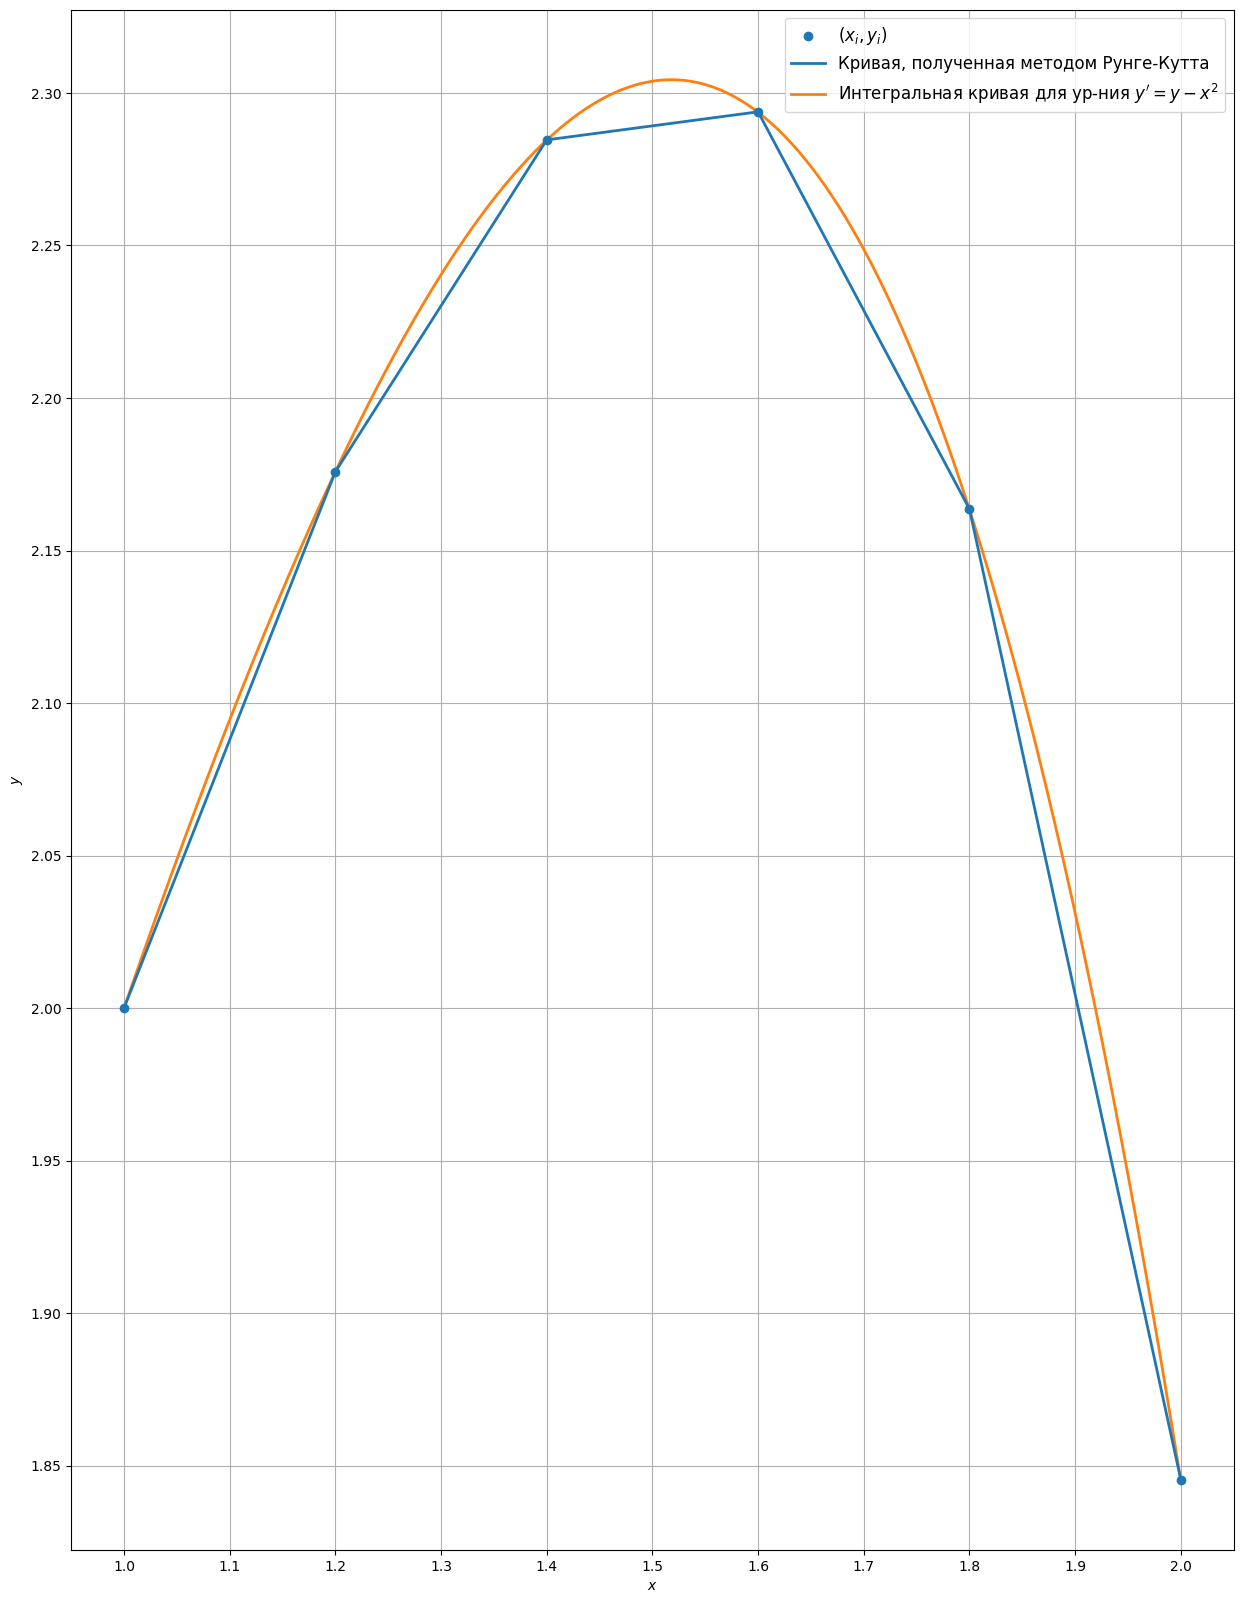

In [117]:
figure, axes = plt.subplots(figsize=(15, 20))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
axes.set_xticks(np.arange(X3[0], X3[-1] + 0.1, 0.1))
axes.set_yticks(np.arange(Y3[0] - 1, max(Y3) + 0.05, 0.05))

axes.scatter(X3, Y3, zorder=2, label=r"$(x_i, y_i)$")
axes.plot(X3, Y3, zorder=2, linewidth=2, label=r"Кривая, полученная методом Рунге-Кутта")

true_X = np.arange(1, 2, 0.001)
true_Y = true_X ** 2 + 2 * true_X + 2 - 3 * np.e ** (true_X - 1)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y'=y-x^2$")


axes.grid()
axes.legend(fontsize="large")

### Графическое сравнение

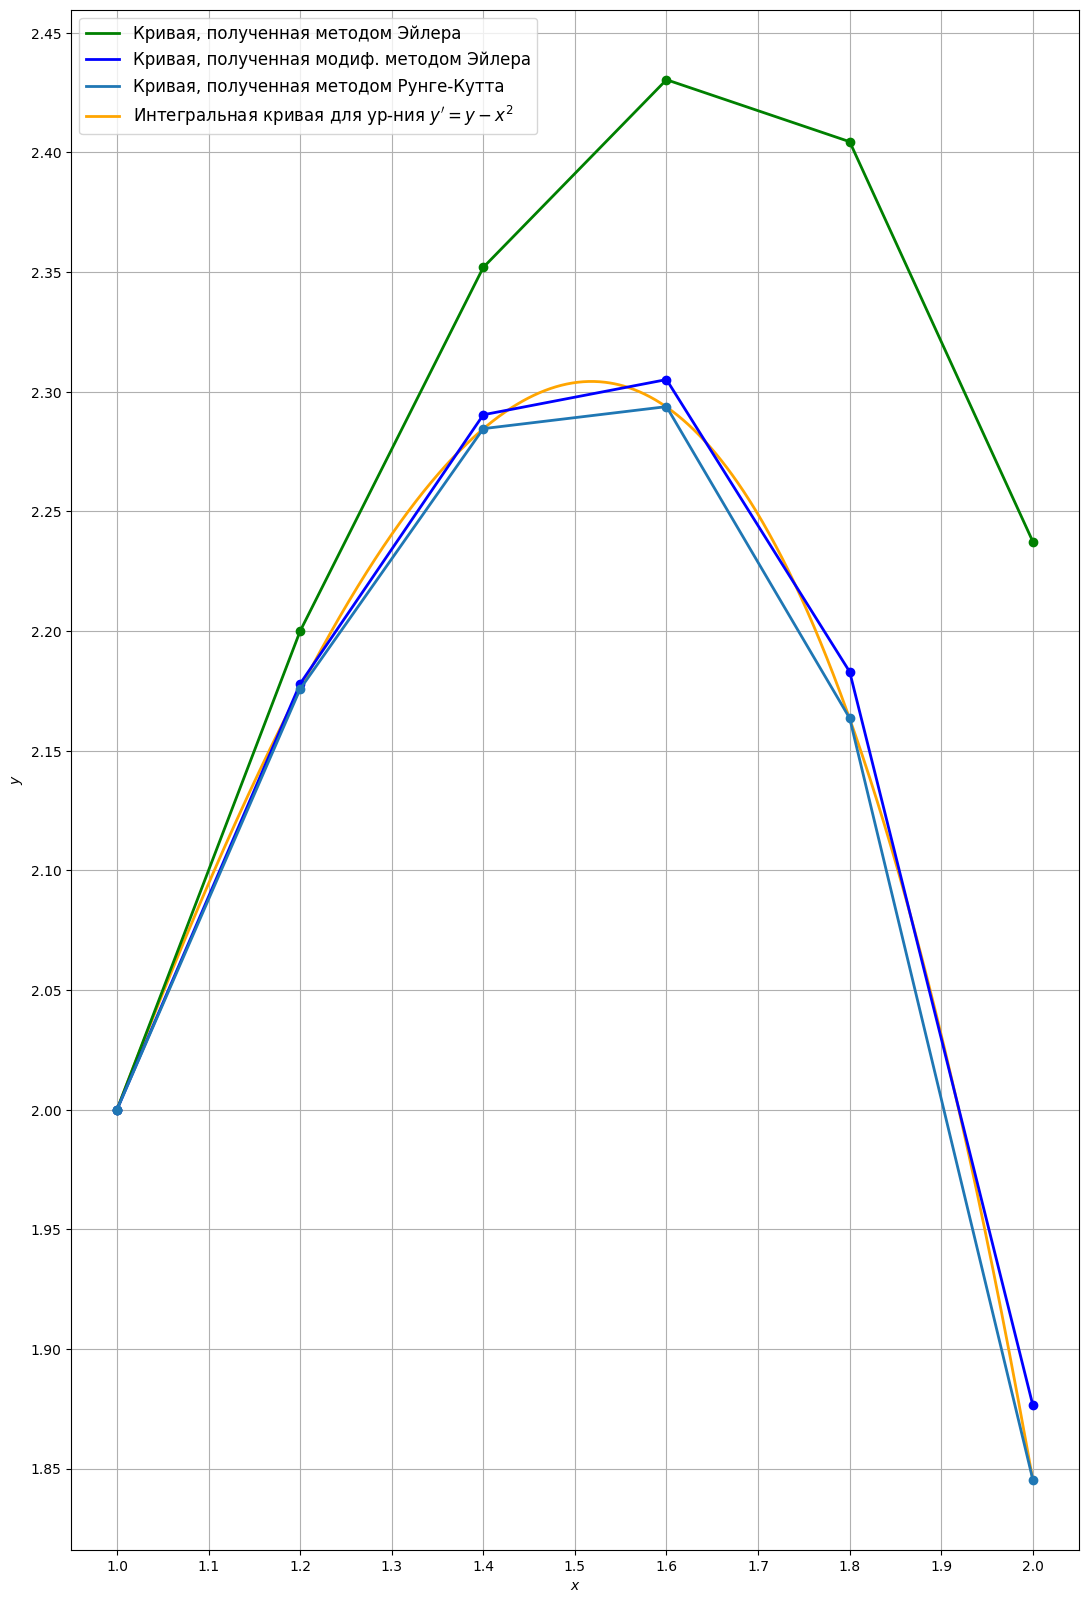

In [ ]:
figure, axes = plt.subplots(figsize=(13, 20))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
axes.set_xticks(np.arange(X[0], X[-1] + 0.1, 0.1))
axes.set_yticks(np.arange(Y[0] - 1, max(Y) + 0.05, 0.05))

axes.scatter(X, Y, zorder=2, color="green")
axes.plot(X, Y, zorder=2, linewidth=2, label=r"Кривая, полученная методом Эйлера", color="green")

axes.scatter(X2, Y2, zorder=2, color="blue")
axes.plot(X2, Y2, zorder=2, linewidth=2, label=r"Кривая, полученная модиф. методом Эйлера", color="blue")

axes.scatter(X3, Y3, zorder=2)
axes.plot(X3, Y3, zorder=2, linewidth=2, label=r"Кривая, полученная методом Рунге-Кутта")

true_X = np.arange(1, 2, 0.001)
true_Y = true_X ** 2 + 2 * true_X + 2 - 3 * np.e ** (true_X - 1)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y'=y-x^2$", color="orange")


axes.grid()
axes.legend(fontsize="large")